In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMinMax


%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 16, 5
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')

/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


## Скачиваем несколько временных рядов с ЭКГ разных пациентов

In [2]:
import wfdb
from collections import Counter

records = ['100', '103',         # норма (N)
            '119', '106', '221', # желудочковые (V)
            '207', '210', '212', '214', # (V, L, R)
            ]

for rec in records:
    wfdb.dl_database('mitdb', 'mitdb_data', records=[rec])
    print(f"Скачана запись {rec}")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Скачана запись 100
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
Скачана запись 103
Generating record list for: 119
Generating list of all files for: 119
Finished downloading files
Скачана запись 119
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
Скачана запись 106
Generating record list for: 221
Generating list of all files for: 221
Finished downloading files
Скачана запись 221
Generating record list for: 207
Generating list of all files for: 207
Finished downloading files
Скачана запись 207
Generating record list for: 210
Generating list of all files for: 210
Finished downloading files
Скачана запись 210
Generating record list for: 212
Generating list of all files for: 212
Finished downloading files
Скачана запись 212
Generating record list for: 214
Generating list of all files for: 214
Fi

#### Извлекаем из медицинский временных рядов отрезки с ударами

In [3]:
def extract_heartbeats_preserving_amplitude(record_names, window_before=120, window_after=180, ):
    all_segments = []
    all_labels = []
    all_sources = []
    all_amplitudes = []
    
    window_size = window_before + window_after
    
    limits = {'N' : 500,
              'V' : 500,
              'A' : 0,
              'L' : 500,
              'R' : 500,
              'random' : 0}
    

    for rec_name in record_names:
        record = wfdb.rdrecord(f'mitdb_data/{rec_name}')
        annotation = wfdb.rdann(f'mitdb_data/{rec_name}', 'atr')
        
        signal = record.p_signal[:, 0]
        
        global_median = np.median(signal)
        signal_centered = signal - global_median
        
        skip_labels = {'?', 'Q', '+', '~'}
        
        for sample, symbol in zip(annotation.sample, annotation.symbol):
            if symbol in skip_labels:
                continue
            
            if symbol in limits:
                if limits[symbol] <= 0:
                    continue
                else:
                    limits[symbol] -= 1
            else:
                if limits['random'] <= 0:
                    continue
                else:
                    limits['random'] -= 1

            start = max(0, sample - window_before)
            end = min(len(signal_centered), sample + window_after)
            
            if end - start == window_size:
                segment = signal_centered[start:end]
                
                amplitude = np.max(np.abs(segment))
                
                all_segments.append(segment)
                all_labels.append(symbol)
                all_sources.append(rec_name)
                all_amplitudes.append(amplitude)
    
    return np.array(all_segments), all_labels, all_sources, all_amplitudes

## Кластаризуем

Segments: (1998, 300)
PCA shape: (1998, 10)
Количество кластеров: 3
Шумовых точек: 273
Silhouette score: 0.26599773399337084


/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:374: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A @ Q)
/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath.py:375: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/Users/alexander/Desktop/AI360_team19/.venv/lib/python3.13/site-packages/sklearn/utils/extmath

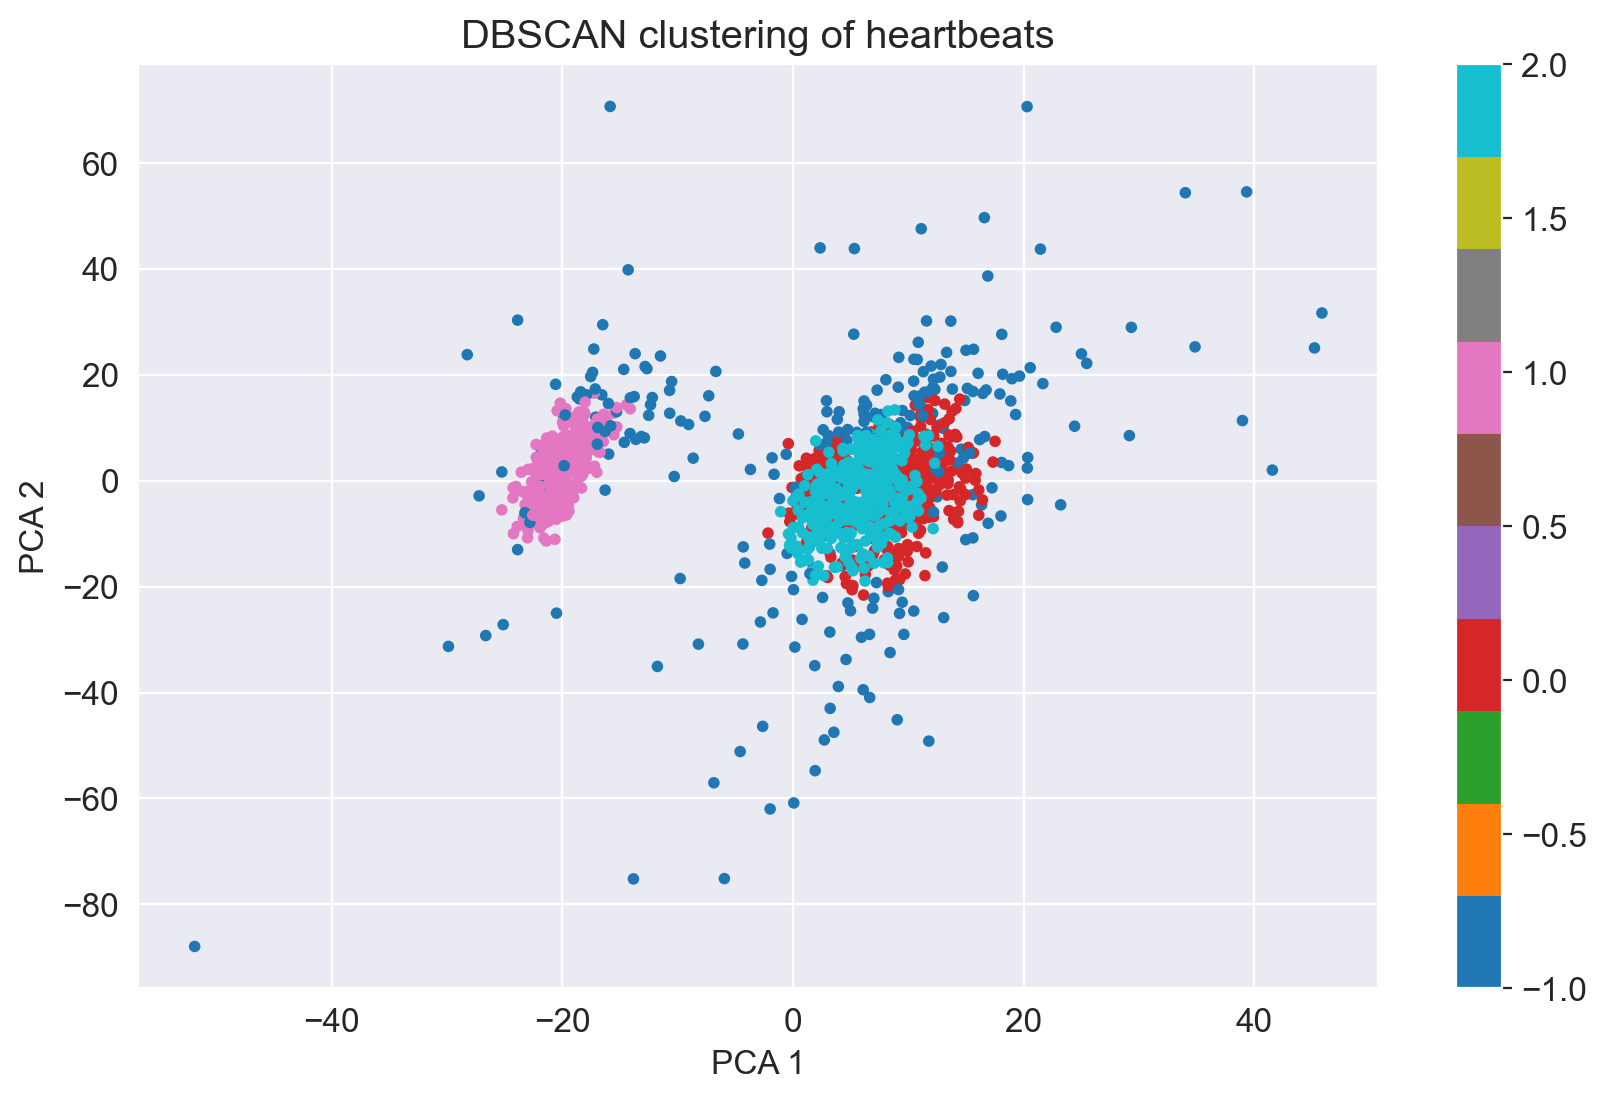

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# -----------------------------
# Параметры окна
# -----------------------------
WINDOW_BEFORE = 120
WINDOW_AFTER = 180

segments, labels, sources, amplitudes = extract_heartbeats_preserving_amplitude(records)

# shape -> (N, T)
print("Segments:", segments.shape)

# -----------------------------
# Подготовка данных
# -----------------------------

# DBSCAN работает с 2D:
# (samples, features)

X = segments.copy()

# Нормализация каждого сердцебиения
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# PCA для снижения размерности
# -----------------------------
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("PCA shape:", X_pca.shape)

# -----------------------------
# DBSCAN
# -----------------------------
dbscan = DBSCAN(
    eps=5,
    min_samples=25,
    metric='euclidean'
)

clusters = dbscan.fit_predict(X_pca)

# -----------------------------
# Анализ
# -----------------------------
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
noise_points = np.sum(clusters == -1)

print("Количество кластеров:", n_clusters)
print("Шумовых точек:", noise_points)

# silhouette только если >1 кластера
if n_clusters > 1:
    score = silhouette_score(X_pca, clusters)
    print("Silhouette score:", score)

# -----------------------------
# Визуализация
# -----------------------------
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='tab10',
    s=10
)

plt.title("DBSCAN clustering of heartbeats")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

## Визуализируем

Кластеры: [-1  0  1  2]


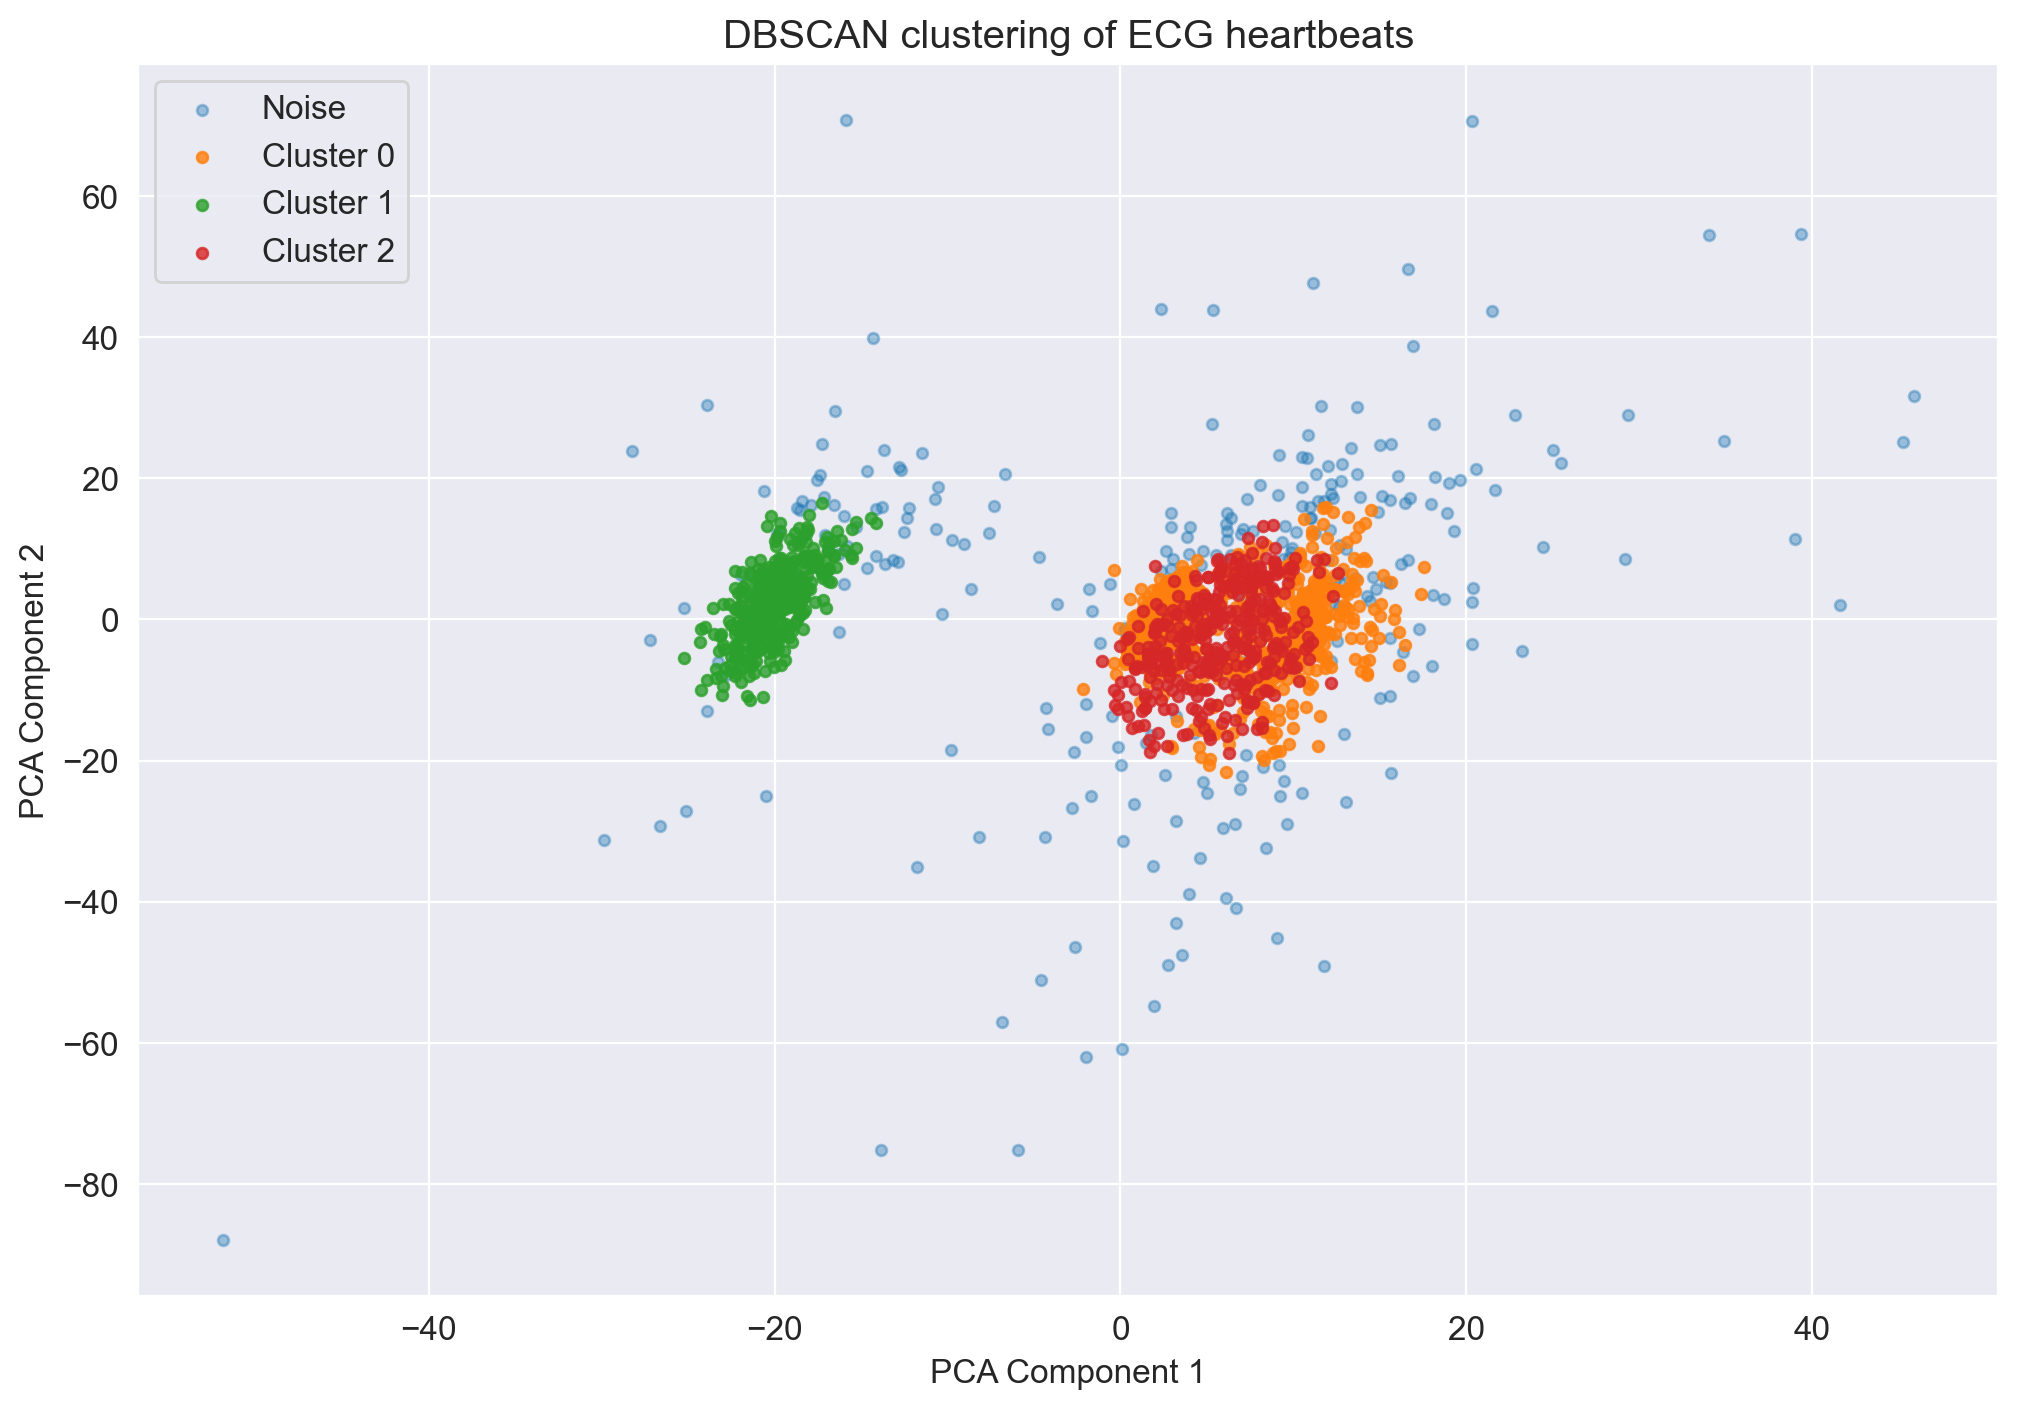


Cluster 0
Samples: 948


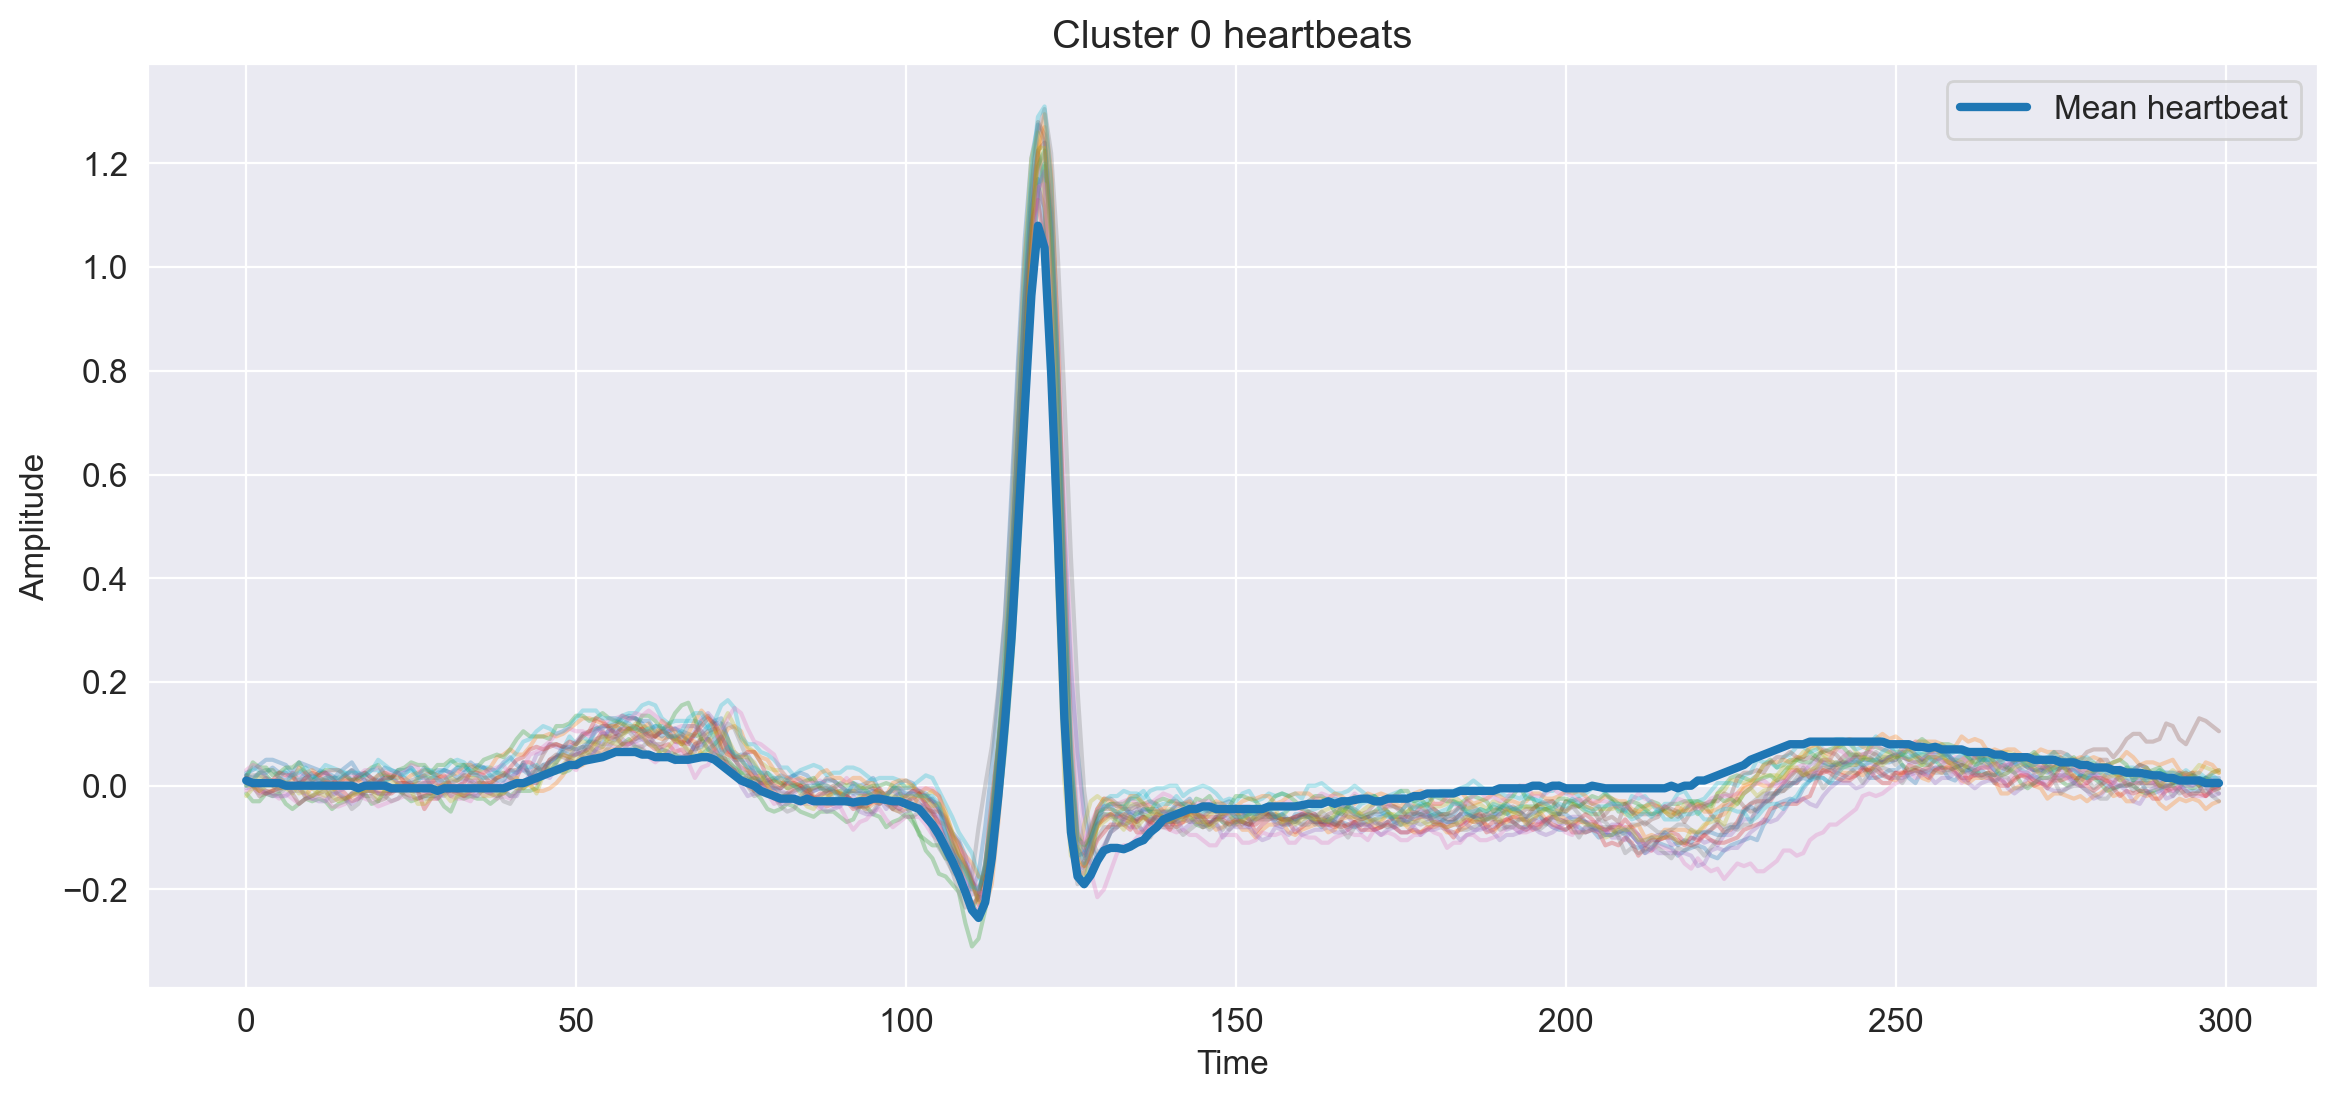


Cluster 1
Samples: 402


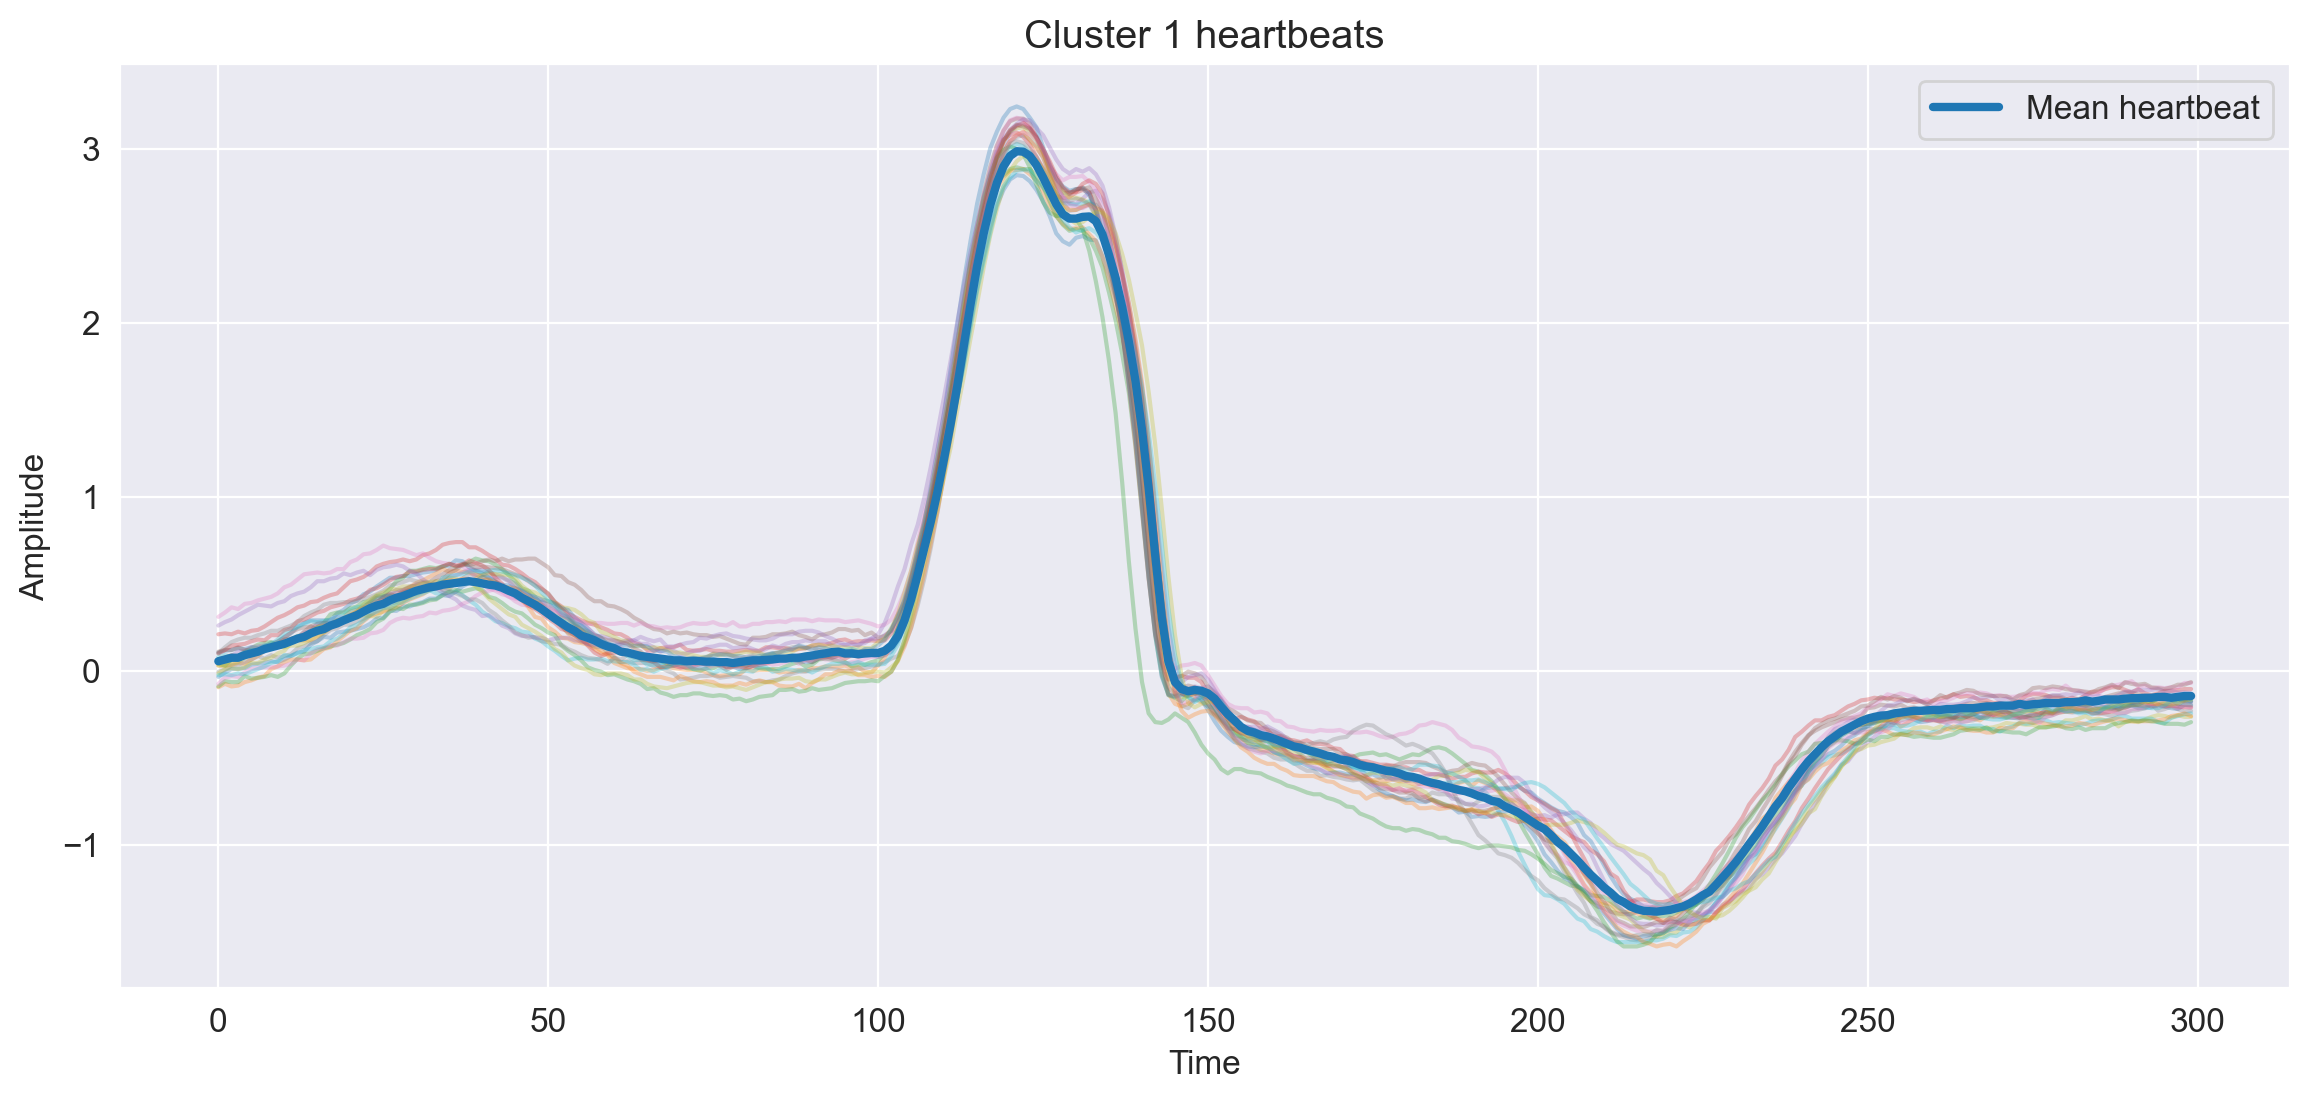


Cluster 2
Samples: 375


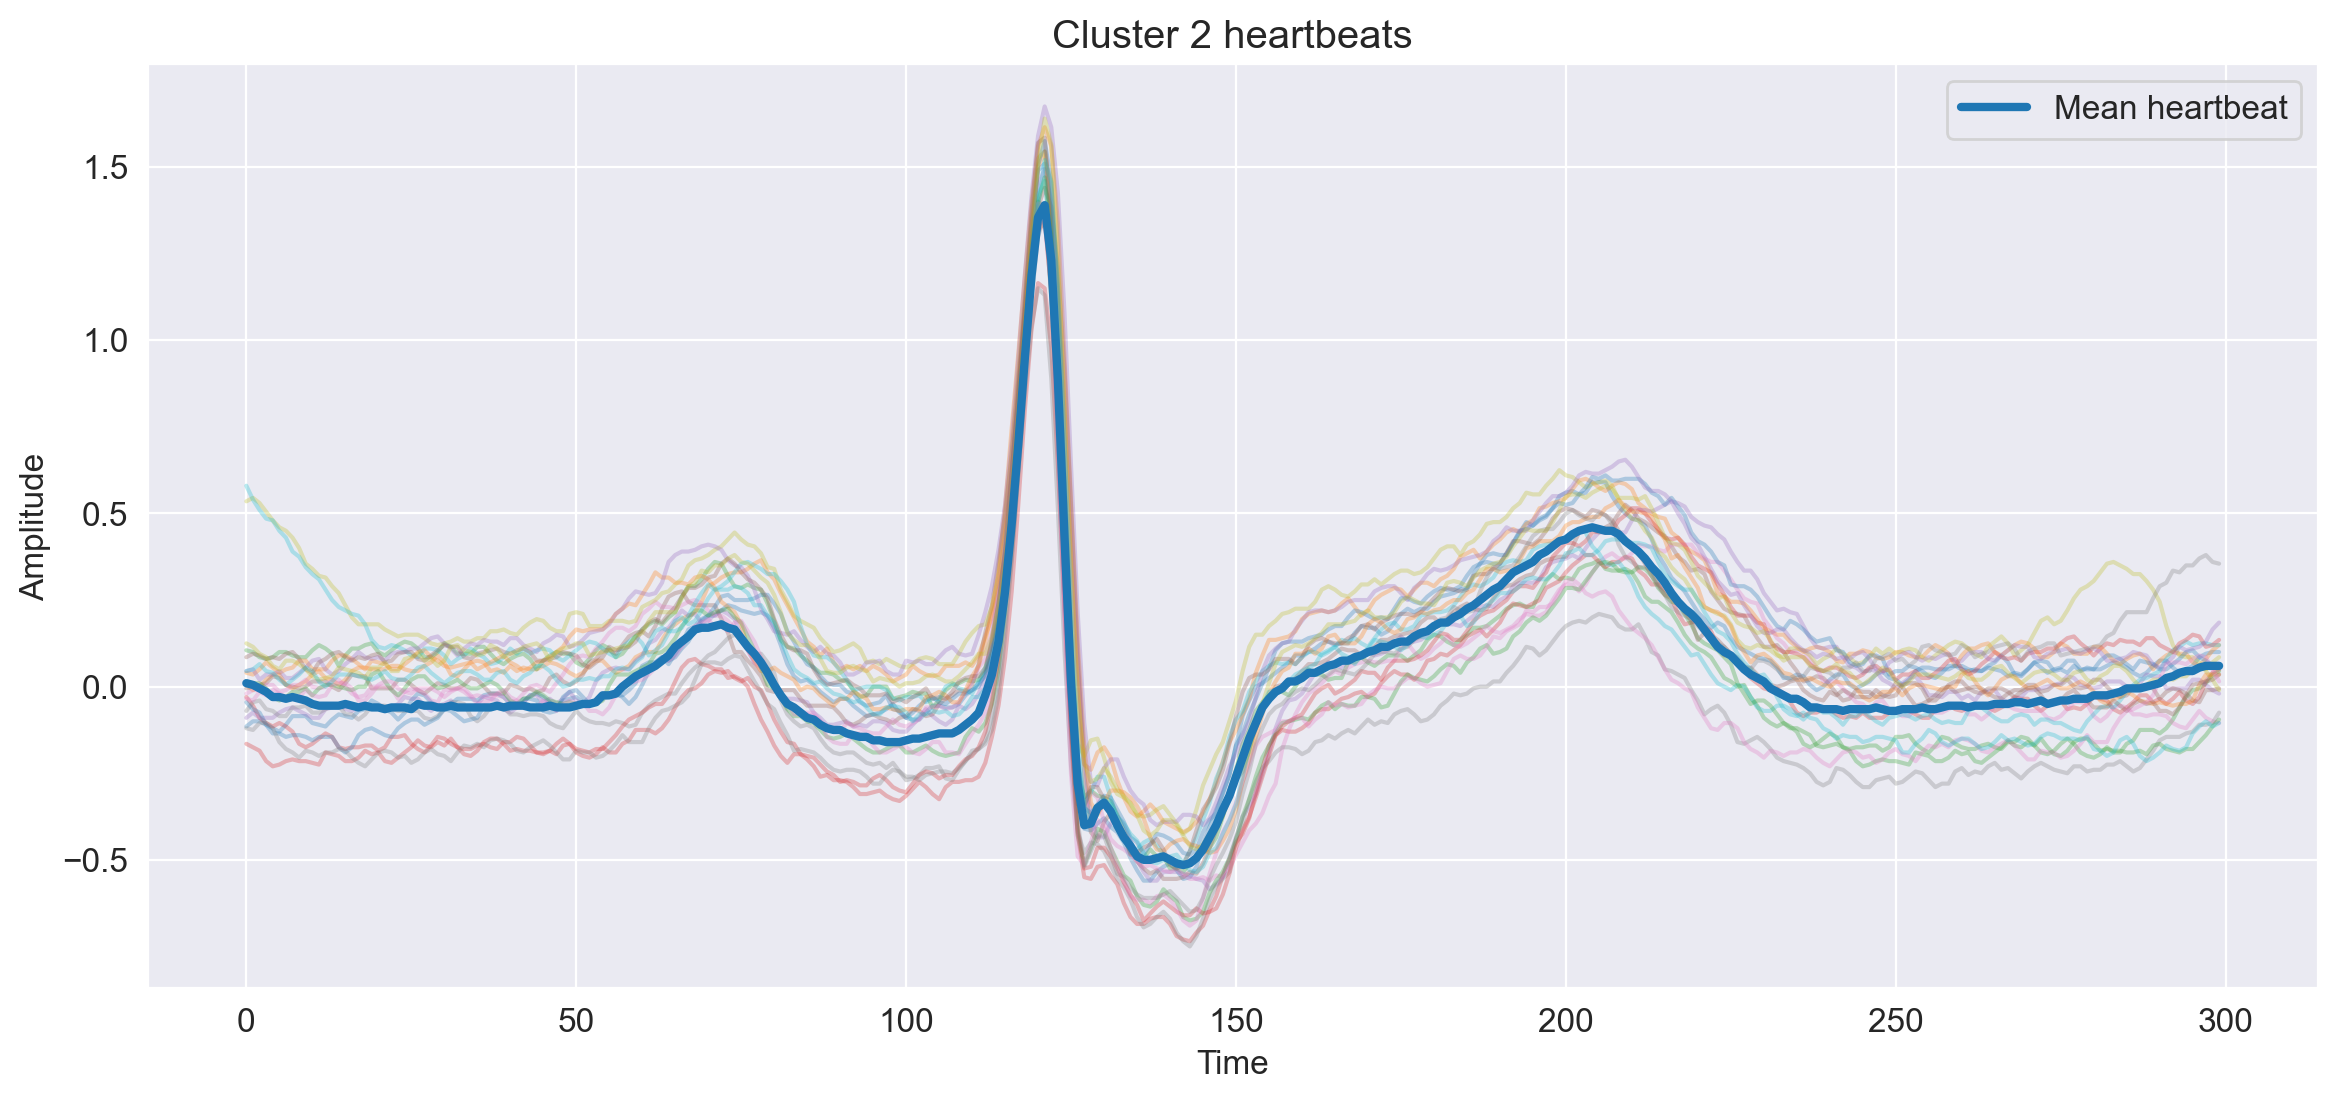

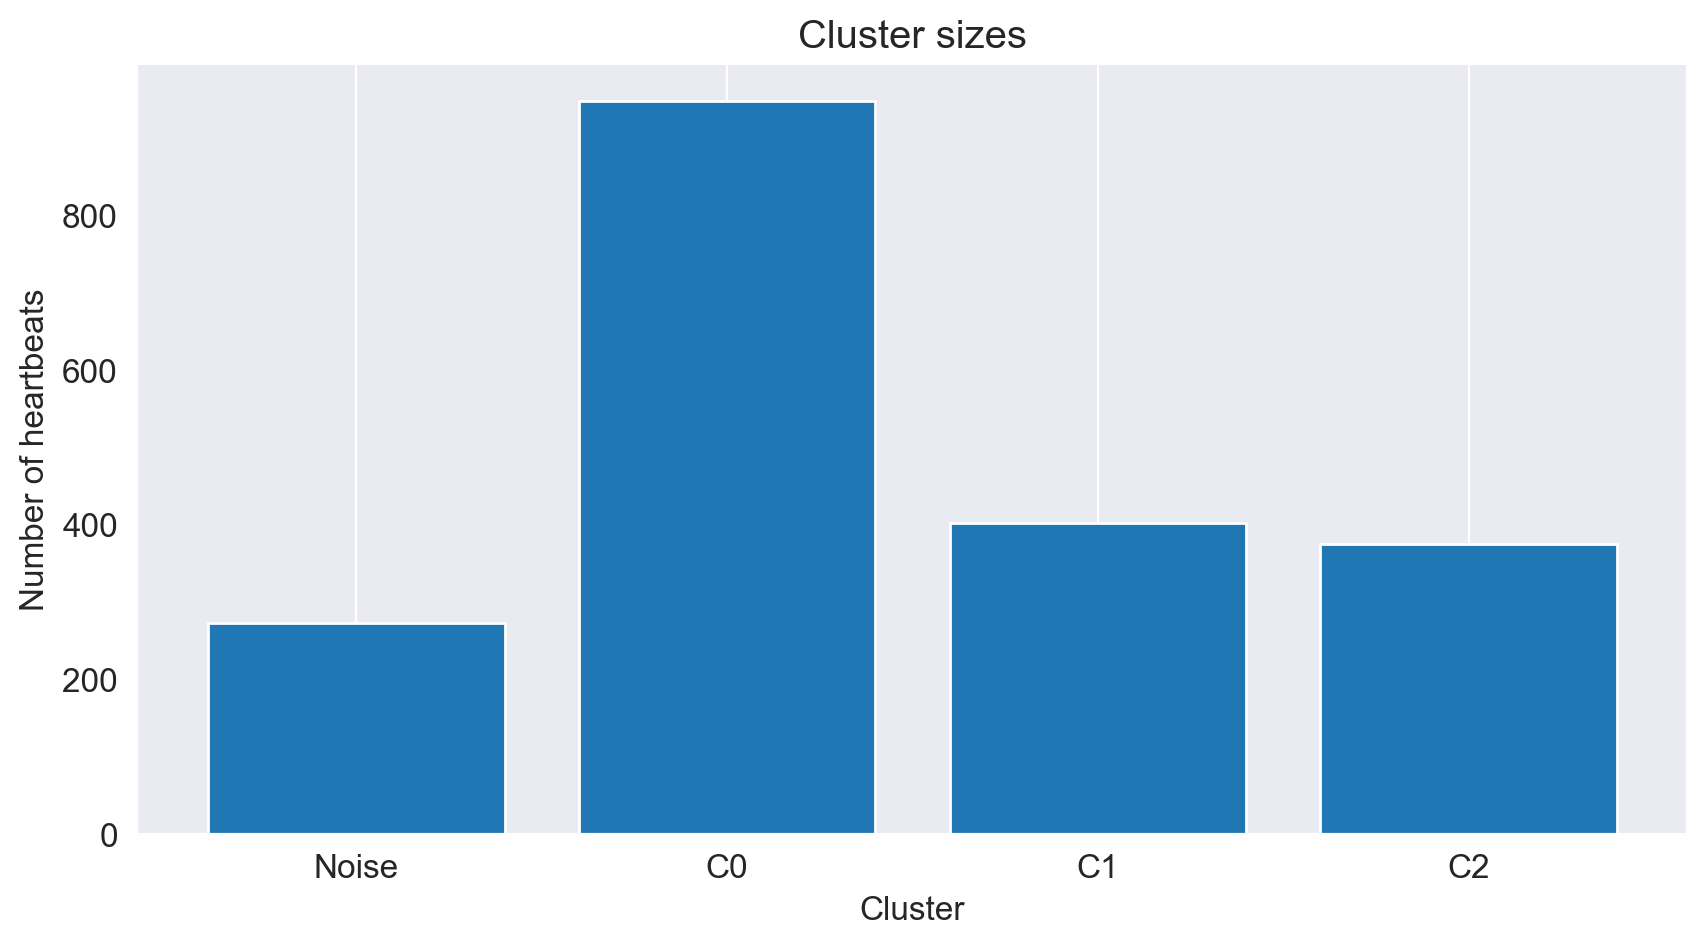

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Визуализация кластеров DBSCAN
# ==========================================

unique_clusters = np.unique(clusters)

print("Кластеры:", unique_clusters)

# ------------------------------------------
# PCA scatter plot
# ------------------------------------------

plt.figure(figsize=(12, 8))

for cluster_id in unique_clusters:
    
    mask = clusters == cluster_id
    
    if cluster_id == -1:
        label = "Noise"
        alpha = 0.4
    else:
        label = f"Cluster {cluster_id}"
        alpha = 0.8

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=15,
        alpha=alpha,
        label=label
    )

plt.title("DBSCAN clustering of ECG heartbeats")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Визуализация формы сердцебиений
# ==========================================

for cluster_id in unique_clusters:

    if cluster_id == -1:
        continue

    cluster_segments = segments[clusters == cluster_id]

    print(f"\nCluster {cluster_id}")
    print("Samples:", len(cluster_segments))

    # Ограничим количество отображаемых сигналов
    n_show = min(20, len(cluster_segments))

    plt.figure(figsize=(14, 6))

    # Отдельные сигналы
    for i in range(n_show):
        plt.plot(
            cluster_segments[i],
            alpha=0.3
        )

    # Средний сигнал
    median_signal = np.median(cluster_segments, axis=0)

    plt.plot(
        median_signal,
        linewidth=3,
        label='Mean heartbeat'
    )

    plt.title(f"Cluster {cluster_id} heartbeats")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

    plt.show()

# ==========================================
# Размеры кластеров
# ==========================================

cluster_sizes = []

cluster_names = []

for cluster_id in unique_clusters:
    
    size = np.sum(clusters == cluster_id)
    
    cluster_sizes.append(size)

    if cluster_id == -1:
        cluster_names.append("Noise")
    else:
        cluster_names.append(f"C{cluster_id}")

plt.figure(figsize=(10, 5))

plt.bar(cluster_names, cluster_sizes)

plt.title("Cluster sizes")
plt.xlabel("Cluster")
plt.ylabel("Number of heartbeats")

plt.grid(axis='y')

plt.show()

## Визуализируем Noise

Количество шумовых сегментов: 273


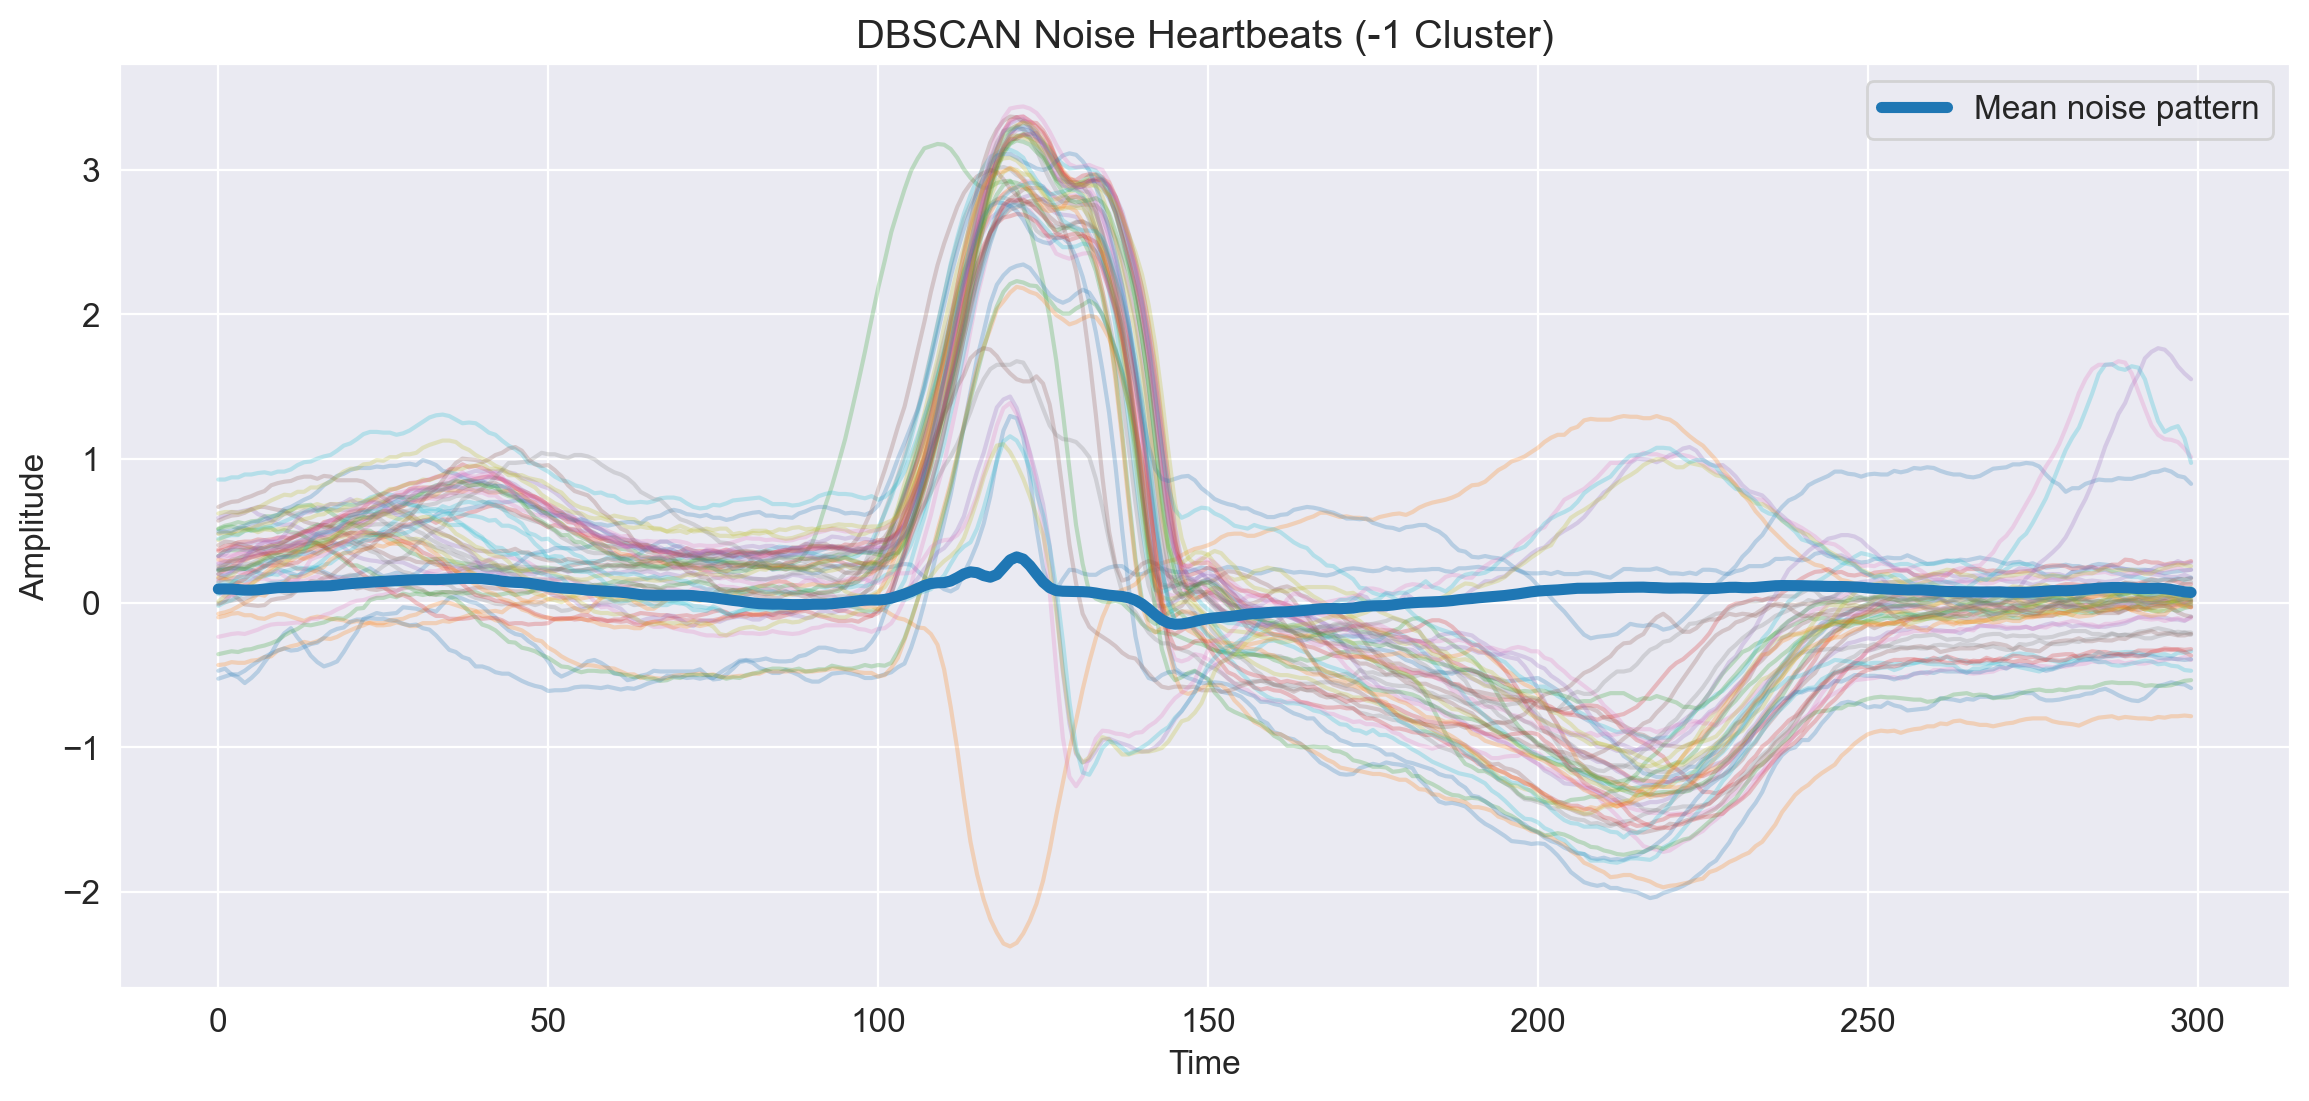

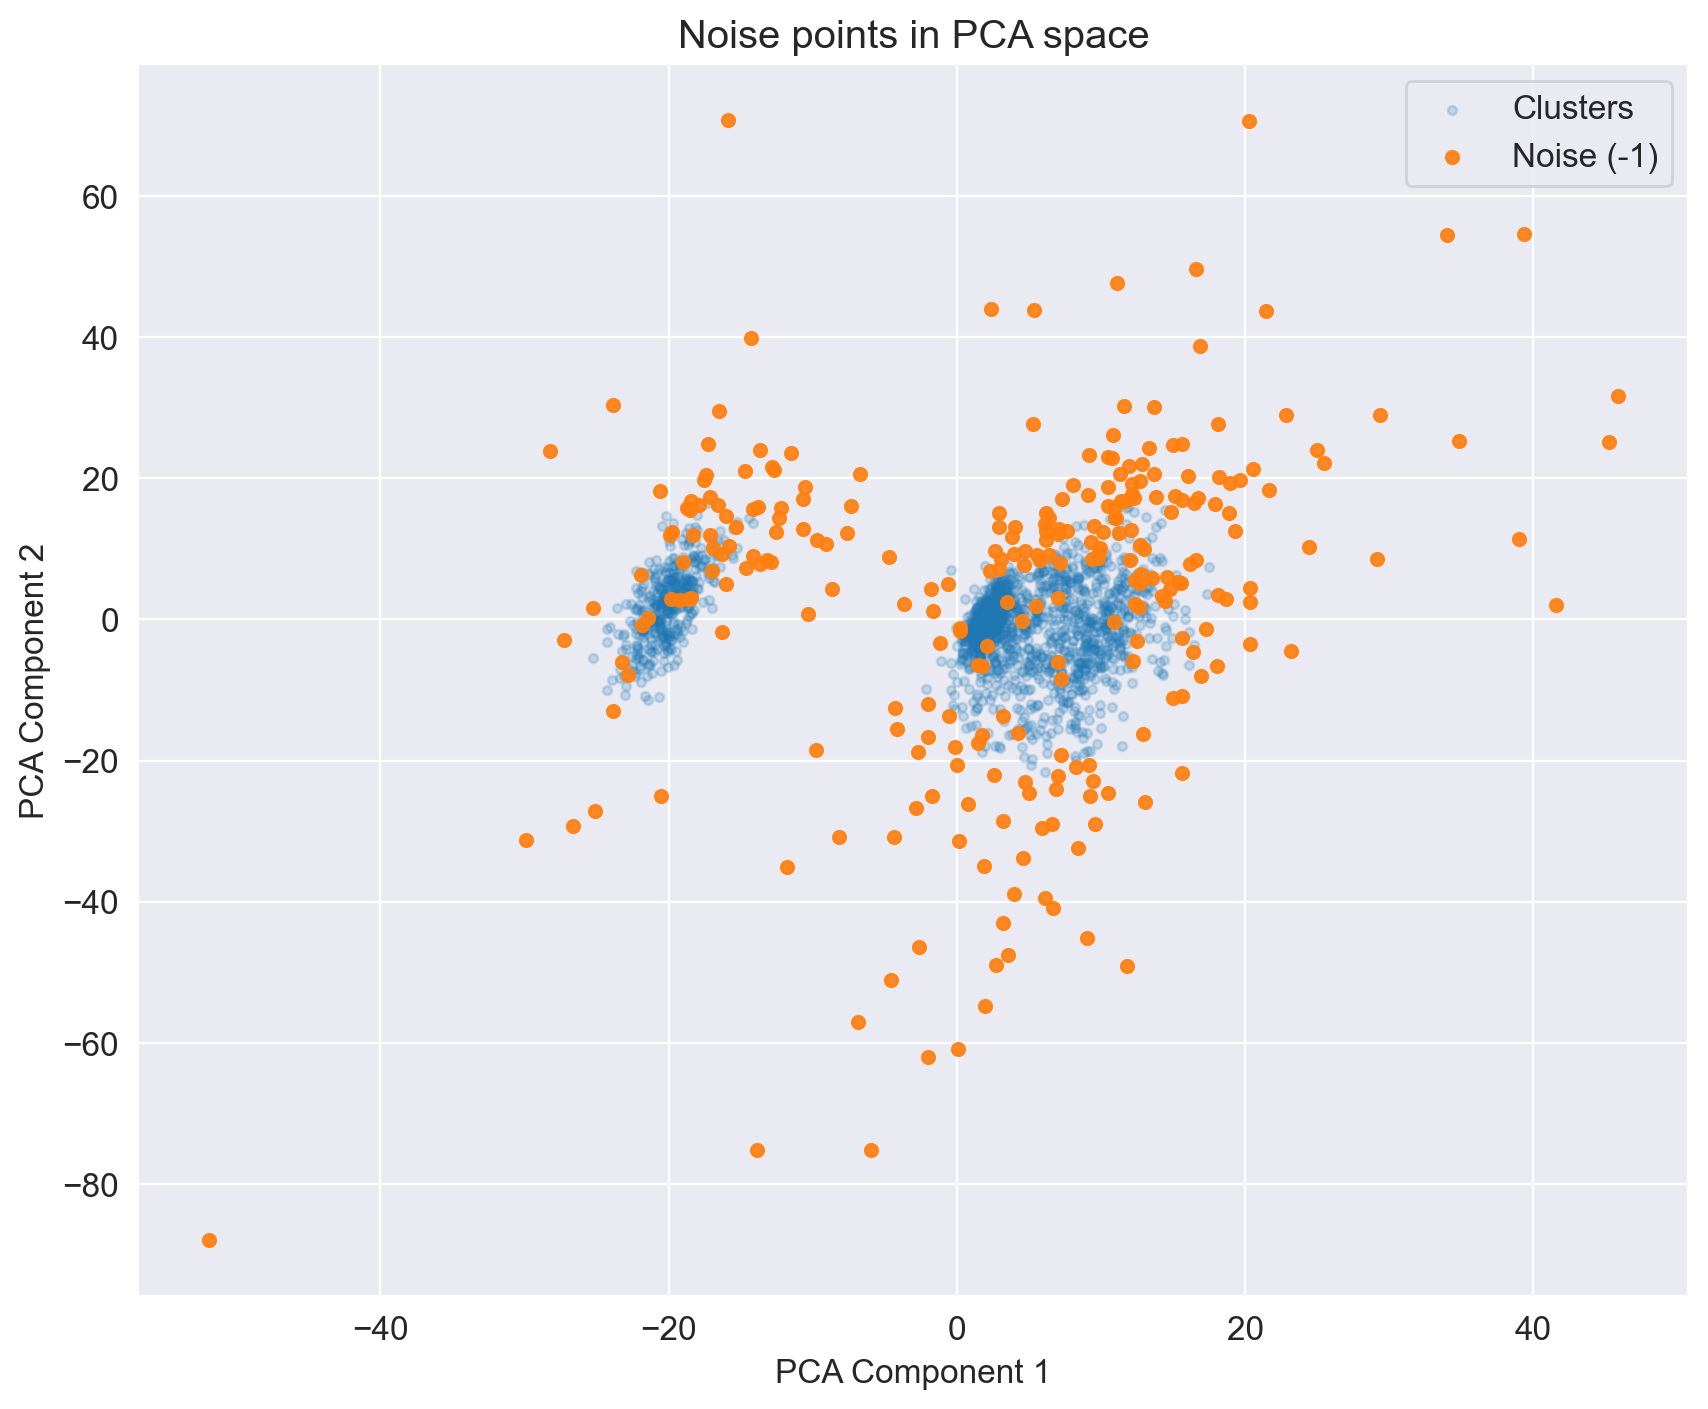

In [6]:
# ==========================================
# Отдельная визуализация Noise (-1)
# ==========================================

noise_segments = segments[clusters == -1]

print("Количество шумовых сегментов:", len(noise_segments))

if len(noise_segments) > 0:

    plt.figure(figsize=(14, 6))

    # Покажем максимум 50 шумовых сигналов
    n_show = min(50, len(noise_segments))

    for i in range(n_show):
        plt.plot(
            noise_segments[i],
            alpha=0.25
        )

    # Средний шумовой сигнал
    mean_noise = np.mean(noise_segments, axis=0)

    plt.plot(
        mean_noise,
        linewidth=4,
        label='Mean noise pattern'
    )

    plt.title("DBSCAN Noise Heartbeats (-1 Cluster)")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)

    plt.show()

# ==========================================
# Noise в PCA пространстве
# ==========================================

plt.figure(figsize=(10, 8))

# Все нормальные точки
normal_mask = clusters != -1

plt.scatter(
    X_pca[normal_mask, 0],
    X_pca[normal_mask, 1],
    s=10,
    alpha=0.2,
    label='Clusters'
)

# Noise отдельно
noise_mask = clusters == -1

plt.scatter(
    X_pca[noise_mask, 0],
    X_pca[noise_mask, 1],
    s=20,
    alpha=0.9,
    label='Noise (-1)'
)

plt.title("Noise points in PCA space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)

plt.show()